# Phase 2: Building Machine Learning Models

In this phase, we will load our perfectly cleaned datasets from Phase 1 and build models to predict Customer Churn.

We will train identical models on two different versions of our data to see which performs better:
1. **MinMax Scaled Data:** Features are squished between 0 and 1.
2. **Standard Scaled Data:** Features are centered around a mean of 0 with a standard deviation of 1.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

## 1. Load the Data
Let's load both of the CSV files we created in Phase 1.

In [52]:
data = pd.read_csv('Telco-Customer-Churn-MinMax.csv')
df = pd.DataFrame(data)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,0.013889,0,1,0.11,0.003339,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.472222,1,0,0.38,0.217526,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,0.027778,1,1,0.35,0.012437,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.625000,0,0,0.24,0.211884,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0.027778,1,1,0.52,0.017388,1,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,0.333333,1,1,0.66,0.229157,0,...,1,0,1,0,1,1,0,0,0,1
7039,0,0,1,1,1.000000,1,1,0.85,0.847766,0,...,0,0,1,0,1,1,0,1,0,0
7040,0,0,1,1,0.152778,0,1,0.11,0.039843,0,...,0,0,0,0,0,0,0,0,1,0
7041,1,1,1,0,0.055556,1,1,0.56,0.035237,1,...,0,0,0,0,0,0,0,0,0,1


first by minmax scaling dataset

In [53]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

## 2. Train-Test Split (Data Segregation)
Before training any Machine Learning model, it is crucial to divide our dataset into two distinct parts:
1. **Training Set ($80\%$):** The data the model learns from. It looks at the features and the answers to find patterns.
2. **Testing Set ($20\%$):** The "unseen" data used to evaluate how well the model generalizes to new, real-world customers. It simulates the future.

**Key Terminology:**
* `X`: The **Features** or Independent Variables (e.g., tenure, monthly charges, internet service type).
* `y`: The **Target** or Dependent Variable (The answer we want to predict: `Churn`).
* `test_size=0.2`: We allocate exactly $20\%$ of our rows to the test set to evaluate performance.
* `random_state=42`: A seed for the random number generator. It guarantees that the random shuffle is exactly the same every time you run the code, making your results **deterministic and reproducible**.

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data Size:", X_train.shape) 
print("Testing Data Size:", X_test.shape)

Training Data Size: (5634, 30)
Testing Data Size: (1409, 30)


In [55]:
linear = LinearRegression()
linear

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Accuracy Score: 0.8232789212207239

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.71      0.57      0.63       373

    accuracy                           0.82      1409
   macro avg       0.78      0.74      0.76      1409
weighted avg       0.82      0.82      0.82      1409



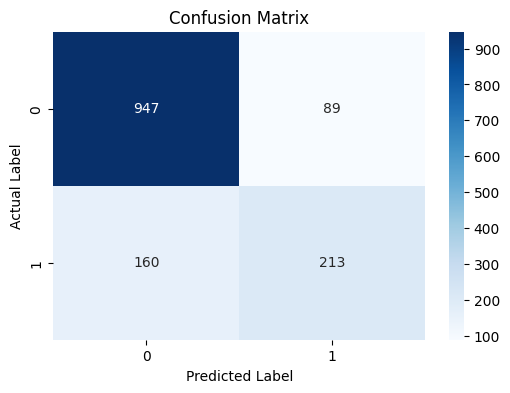

In [56]:
linear.fit(X_train, y_train)
y_test_pred = linear.predict(X_test)
y_test_pred = (y_test_pred > 0.5).astype(int)

# 1. Accuracy Score
print("Accuracy Score:", accuracy_score(y_test, y_test_pred))

# 2. Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

## 4. Understanding Evaluation Metrics
In Machine Learning, how you score a model depends entirely on what the model is trying to predict. There is a strict divide between **Regression Metrics** and **Classification Metrics**.

### A. Regression Metrics (Predicting Continuous Numbers)
When you are predicting a number (like the price of a house or next month's total sales), you cannot just say a model is "wrong" if it predicts $300,001 instead of $300,000. You measure the *distance of the error*.
* **Mean Absolute Error (MAE):** The average absolute distance between the prediction and the actual value.
  $$MAE = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|$$
* **Mean Squared Error (MSE):** Squares the errors before averaging them, heavily penalizing large outliers.
  $$MSE = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
* **Root Mean Squared Error (RMSE):** The square root of the MSE, bringing the error metric back into the original units of prediction.
  $$RMSE = \sqrt{MSE}$$


* **R-Squared ($R^2$ Score):** Represents the proportion of the variance in the dependent variable ($y$) that is predictable from the independent variables ($x$). It shows how well the data fits the regression model.
  $$R^2 = 1 - \frac{Sum\ of\ Squared\ Residuals\ (SSR)}{Total\ Sum\ of\ Squares\ (SST)}$$
* **Residuals:** The difference between the observed value and the predicted value. A model is considered good if its residuals are small and randomly scattered around zero.
  $$Residual = y_i - \hat{y}_i$$

---


### B. Classification Metrics (Predicting Categories / Yes or No)  <- WE ARE USING THESE
When you are predicting a strict category (like "Will Churn" or "Will Not Churn"), the prediction is either exactly right or exactly wrong. We measure the *count* of correct vs. incorrect buckets.

**1. The Confusion Matrix**
The foundation of all classification metrics. It categorizes predictions into four absolute buckets:
* **True Positives (TP):** We predicted Churn ($1$), and they actually Churned ($1$).
* **True Negatives (TN):** We predicted No Churn ($0$), and they actually Didn't Churn ($0$).
* **False Positives (FP) [Type I Error]:** We predicted Churn ($1$), but they Didn't Churn ($0$). *(False Alarm)*
* **False Negatives (FN) [Type II Error]:** We predicted No Churn ($0$), but they actually Churned ($1$). *(Missed Opportunity)*

**2. Accuracy Score**
The percentage of total predictions the model got completely right. Best used when the dataset is perfectly balanced (equal amounts of churn and non-churn rows).
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

**3. Precision (Quality of Positive Predictions)**
"Out of all the customers we *predicted* would churn, how many *actually* churned?"
$$Precision = \frac{TP}{TP + FP}$$
*High Precision means very few False Positives.*

**4. Recall / Sensitivity (Quantity of Positive Predictions)**
"Out of all the customers who *actually* churned, how many did we successfully *find*?"
$$Recall = \frac{TP}{TP + FN}$$
*High Recall means very few False Negatives (we successfully identified most of the positive cases).*

**5. F1-Score**
The harmonic mean of Precision and Recall. It is the gold standard metric when your dataset is imbalanced (e.g., when you have significantly more No Churners than Churners).
$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$